/home/robinalex/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Features: ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Pressure (millibars)']
Target:   Apparent Temperature (C)

Coefficients:
  Intercept:              -2.5322
  Temperature (C)             1.1259
  Humidity                    1.0636
  Wind Speed (km/h)           -0.0949
  Pressure (millibars)        0.0002

MSE:  1.1661
RMSE: 1.0799


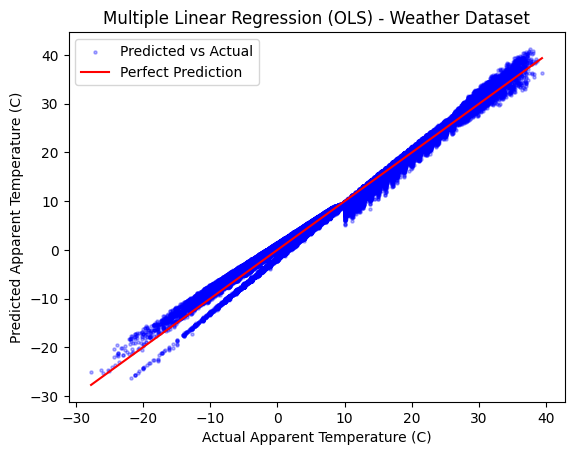

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def compute_coefficients(X, y):
    """
    Computes OLS coefficients using the normal equation: β = (XᵀX)⁻¹ Xᵀy
    X: 2D array (n_samples, n_features)
    y: 1D array (n_samples,)
    Returns: coefficients array [intercept, w1, w2, ..., wn]
    """
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    coefficients = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    return coefficients


def predict(X, coefficients):
    """
    Predicts y = X_b @ β
    X: 2D array (n_samples, n_features)
    coefficients: [intercept, w1, w2, ..., wn]
    """
    ones = np.ones((X.shape[0], 1))
    X_b = np.hstack([ones, X])
    return X_b @ coefficients


def evaluate(y, y_hat):
    mse = np.mean((y - y_hat) ** 2)
    return mse, np.sqrt(mse)


# ── Load Weather Dataset ──

df = pd.read_csv("weatherHistory.csv")
df = df.dropna()

feature_cols = ["Temperature (C)", "Humidity", "Wind Speed (km/h)", "Pressure (millibars)"]
target_col = "Apparent Temperature (C)"

X = df[feature_cols].values
y = df[target_col].values

# Compute and predict
coefficients = compute_coefficients(X, y)
y_hat = predict(X, coefficients)

print(f"Features: {feature_cols}")
print(f"Target:   {target_col}")
print(f"\nCoefficients:")
print(f"  Intercept:              {coefficients[0]:.4f}")
for name, coef in zip(feature_cols, coefficients[1:]):
    print(f"  {name:27s} {coef:.4f}")

mse, rmse = evaluate(y, y_hat)
print(f"\nMSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")

# Plot actual vs predicted
plt.scatter(y, y_hat, color='blue', alpha=0.3, s=5, label='Predicted vs Actual')
plt.plot([y.min(), y.max()], [y.min(), y.max()], color='red', label='Perfect Prediction')
plt.xlabel(f'Actual {target_col}')
plt.ylabel(f'Predicted {target_col}')
plt.title('Multiple Linear Regression (OLS) - Weather Dataset')
plt.legend()
plt.show()
